# Sphere Function using BCGA

Run  1: Best fitness = 3.504920e+00, Generations = 200, Time = 2.42 s
Run  2: Best fitness = 1.450127e+00, Generations = 200, Time = 2.44 s
Run  3: Best fitness = 3.920770e+00, Generations = 200, Time = 3.43 s
Run  4: Best fitness = 2.829162e+00, Generations = 200, Time = 2.71 s
Run  5: Best fitness = 2.006633e+00, Generations = 200, Time = 2.42 s
Run  6: Best fitness = 4.061426e+00, Generations = 200, Time = 2.40 s
Run  7: Best fitness = 3.003452e+00, Generations = 200, Time = 2.43 s
Run  8: Best fitness = 2.190097e+00, Generations = 200, Time = 3.77 s
Run  9: Best fitness = 4.682144e+00, Generations = 200, Time = 2.45 s
Run 10: Best fitness = 3.312283e+00, Generations = 200, Time = 2.42 s
Run 11: Best fitness = 3.199147e+00, Generations = 200, Time = 2.44 s
Run 12: Best fitness = 1.569378e+00, Generations = 200, Time = 2.40 s
Run 13: Best fitness = 2.492812e+00, Generations = 200, Time = 3.75 s
Run 14: Best fitness = 2.260425e+00, Generations = 200, Time = 2.44 s
Run 15: Best fitness

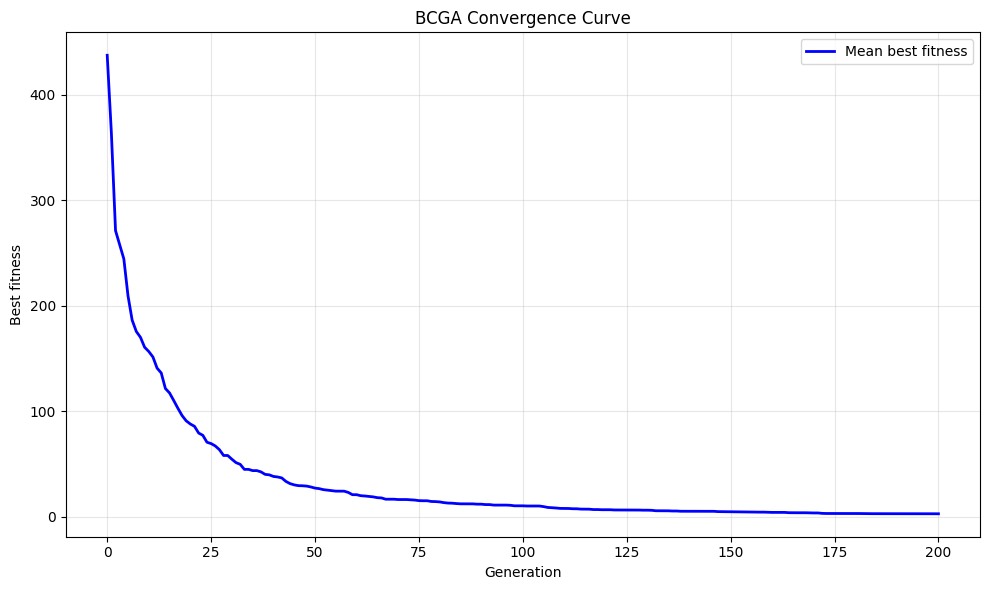

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Sphere Function
def sphere(x):
    return np.sum(x**2)

# BCGA Single Run (optimised for Pm=0.1) with early stopping threshold = 0.01
def bcga_single_run(fitness_func, lb, ub, Np, T, d=10, threshold=0.01, return_history=True):
    BITS = 10
    CHROM_LEN = d * BITS

    Pc = 0.8          # crossover probability
    Pm = 0.1          # mutation probability

    # Uniform crossover helper
    def uniform_crossover(p1, p2):
        mask = np.random.rand(CHROM_LEN) < 0.5
        c1 = ''.join(p1[i] if mask[i] else p2[i] for i in range(CHROM_LEN))
        c2 = ''.join(p2[i] if mask[i] else p1[i] for i in range(CHROM_LEN))
        return c1, c2

    def decode(ch):
        vals = []
        for i in range(d):
            seg = ch[i*BITS:(i+1)*BITS]
            dec = int(seg, 2)
            real = lb + (dec / (2**BITS - 1)) * (ub - lb)
            vals.append(real)
        return np.array(vals)

    def fit(ch):
        return fitness_func(decode(ch))

    def rand_chrom():
        return ''.join(np.random.choice(['0','1'], CHROM_LEN))

    # Initialise population
    population = [rand_chrom() for _ in range(Np)]
    fitness = np.array([fit(ind) for ind in population])

    # Elitism: keep absolute best ever
    best_idx = np.argmin(fitness)
    best_x = decode(population[best_idx])
    best_f = fitness[best_idx]
    history = [best_f]

    for t in range(1, T+1):
        # Early stopping: if best_f <= threshold (0.01), stop
        if best_f <= threshold:
            break

        offspring = []

        while len(offspring) < Np:
            # Tournament selection with size 4 (increased pressure)
            def tournament():
                idx = np.random.choice(Np, 4, replace=False)
                winner = idx[np.argmin(fitness[idx])]
                return population[winner]

            p1 = tournament()
            p2 = tournament()

            # Uniform crossover with probability Pc
            if np.random.rand() < Pc:
                c1, c2 = uniform_crossover(p1, p2)
            else:
                c1, c2 = p1, p2

            # Bit‑flip mutation (Pm = 0.1)
            def mutate(ch):
                bits = list(ch)
                for i in range(CHROM_LEN):
                    if np.random.rand() < Pm:
                        bits[i] = '1' if bits[i] == '0' else '0'
                return ''.join(bits)

            c1, c2 = mutate(c1), mutate(c2)
            offspring.extend([c1, c2])

        offspring = offspring[:Np]

        # (μ + λ) survival selection
        combined = population + offspring
        combined_fitness = np.array([fit(ind) for ind in combined])
        idx = np.argsort(combined_fitness)[:Np]
        population = [combined[i] for i in idx]
        fitness = combined_fitness[idx]

        # Update best
        if fitness[0] < best_f:
            best_f = fitness[0]
            best_x = decode(population[0])

        history.append(best_f)

    if return_history:
        return best_x, best_f, history
    else:
        return best_x, best_f


# Multiple Runs (threshold=0.01)
def run_multiple_times(n_runs=20, Np=100, T=200, lb=-20, ub=20, d=10, threshold=0.01):
    histories = []
    final_fitnesses = []
    run_times = []
    gens_per_run = []

    for run in range(1, n_runs+1):
        start = time.time()
        _, best_f, hist = bcga_single_run(sphere, lb, ub, Np, T, d, threshold=threshold, return_history=True)
        elapsed = time.time() - start
        histories.append(hist)
        final_fitnesses.append(best_f)
        run_times.append(elapsed)
        gens_per_run.append(len(hist) - 1)
        print(f"Run {run:2d}: Best fitness = {best_f:.6e}, Generations = {len(hist)-1}, Time = {elapsed:.2f} s")

    return histories, final_fitnesses, run_times, gens_per_run


# MAIN
if __name__ == "__main__":
    np.random.seed(42)

    n_runs = 20
    Np = 100
    T = 200
    lb, ub = -20, 20
    d = 10

    THRESHOLD = 0.01   # Early stopping threshold

    histories, final_fits, run_times, gens_per_run = run_multiple_times(
        n_runs, Np, T, lb, ub, d, threshold=THRESHOLD
    )

    avg_fit = np.mean(final_fits)
    std_fit = np.std(final_fits)
    best_fit = np.min(final_fits)
    worst_fit = np.max(final_fits)
    avg_time = np.mean(run_times)
    total_time = np.sum(run_times)
    avg_gens = np.mean(gens_per_run)
    std_gens = np.std(gens_per_run)

    print("\n" + "="*50)
    print(f"Summary over {n_runs} runs (Pm = 0.1, optimised selection & crossover)")
    print(f"Early stopping threshold: best_f <= {THRESHOLD}")
    print(f"Average best fitness : {avg_fit:.2e} ± {std_fit:.2e}")
    print(f"Best fitness         : {best_fit:.2e}")
    print(f"Worst fitness        : {worst_fit:.2e}")
    print(f"Average generations  : {avg_gens:.1f} ± {std_gens:.1f} (max {T})")
    print(f"Average time         : {avg_time:.2f} s")
    print(f"Total time           : {total_time:.2f} s")
    print("="*50)

    # ========== CONVERGENCE CURVE ONLY (linear, no shading, no histogram) ==========
    # The curve shows the mean of the best fitness values from all runs at each generation.
    min_len = min(len(h) for h in histories)
    truncated_hist = np.array([h[:min_len] for h in histories])
    mean_hist = np.mean(truncated_hist, axis=0)
    gens = np.arange(min_len)

    plt.figure(figsize=(10, 6))
    plt.plot(gens, mean_hist, 'b-', linewidth=2, label='Mean best fitness')   # Change label if desired
    plt.xlabel('Generation')
    plt.ylabel('Best fitness')
    plt.title(f'BCGA Convergence Curve')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Sphere Function using RCGA

Run  1: Best fitness = 9.668196e-03, Generations = 140, Time = 0.70 s
Run  2: Best fitness = 9.829281e-03, Generations = 117, Time = 0.57 s
Run  3: Best fitness = 8.603000e-03, Generations = 116, Time = 0.62 s
Run  4: Best fitness = 7.481866e-03, Generations = 109, Time = 0.57 s
Run  5: Best fitness = 9.119191e-03, Generations = 143, Time = 0.69 s
Run  6: Best fitness = 9.858583e-03, Generations = 152, Time = 0.77 s
Run  7: Best fitness = 9.916545e-03, Generations = 161, Time = 0.80 s
Run  8: Best fitness = 7.972841e-03, Generations = 152, Time = 0.73 s
Run  9: Best fitness = 9.416287e-03, Generations = 132, Time = 0.66 s
Run 10: Best fitness = 9.764365e-03, Generations = 164, Time = 0.82 s
Run 11: Best fitness = 9.865191e-03, Generations = 145, Time = 0.70 s
Run 12: Best fitness = 9.638006e-03, Generations = 113, Time = 0.80 s
Run 13: Best fitness = 9.003388e-03, Generations = 104, Time = 0.85 s
Run 14: Best fitness = 9.934212e-03, Generations = 108, Time = 1.08 s
Run 15: Best fitness

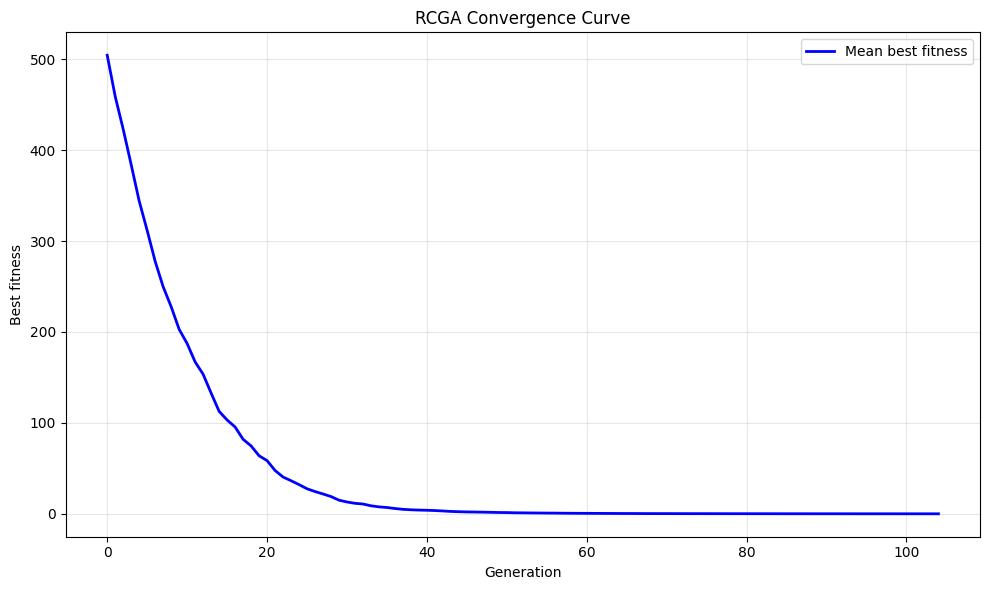

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Sphere Function
def sphere(x):
    return np.sum(x**2)

# RCGA (SBX + Polynomial Mutation) with early stopping threshold = 0.01
def rcga_single_run(fitness_func, lb, ub, Np, T, d=10, threshold=0.01, return_history=True):

    Pc = 0.8
    Pm = 0.1
    eta_c = 15   # SBX parameter
    eta_m = 20   # mutation parameter

    # Initialize
    population = np.random.uniform(lb, ub, (Np, d))
    fitness = np.array([fitness_func(ind) for ind in population])

    best_idx = np.argmin(fitness)
    best_x = population[best_idx].copy()
    best_f = fitness[best_idx]
    history = [best_f]

    for t in range(1, T+1):
        # Early stopping: if best_f <= threshold (0.01), stop
        if best_f <= threshold:
            break

        offspring = []

        while len(offspring) < Np:
            # Tournament Selection
            i, j = np.random.choice(Np, 2)
            p1 = population[i] if fitness[i] < fitness[j] else population[j]

            i, j = np.random.choice(Np, 2)
            p2 = population[i] if fitness[i] < fitness[j] else population[j]

            # SBX Crossover
            if np.random.rand() < Pc:
                u = np.random.rand()
                if u <= 0.5:
                    beta = (2*u)**(1/(eta_c+1))
                else:
                    beta = (1/(2*(1-u)))**(1/(eta_c+1))

                c1 = 0.5*((1+beta)*p1 + (1-beta)*p2)
                c2 = 0.5*((1-beta)*p1 + (1+beta)*p2)
            else:
                c1, c2 = p1.copy(), p2.copy()

            # Polynomial Mutation
            def mutate(x):
                for j in range(d):
                    if np.random.rand() < Pm:
                        r = np.random.rand()
                        if r < 0.5:
                            delta = (2*r)**(1/(eta_m+1)) - 1
                        else:
                            delta = 1 - (2*(1-r))**(1/(eta_m+1))
                        x[j] = x[j] + (ub - lb) * delta
                return np.clip(x, lb, ub)

            c1 = mutate(c1)
            c2 = mutate(c2)

            offspring.extend([c1, c2])

        offspring = np.array(offspring[:Np])

        # (μ + λ) Selection
        combined = np.vstack((population, offspring))
        combined_fitness = np.array([fitness_func(ind) for ind in combined])

        idx = np.argsort(combined_fitness)[:Np]
        population = combined[idx]
        fitness = combined_fitness[idx]

        # Update best
        if fitness[0] < best_f:
            best_f = fitness[0]
            best_x = population[0].copy()

        history.append(best_f)

    if return_history:
        return best_x, best_f, history
    else:
        return best_x, best_f


# Multiple Runs with threshold
def run_multiple_times(n_runs=20, Np=100, T=200, lb=-20, ub=20, d=10, threshold=0.01):
    histories = []
    final_fitnesses = []
    run_times = []
    gens_per_run = []   # to track actual generations used

    for run in range(1, n_runs+1):
        start = time.time()

        _, best_f, hist = rcga_single_run(sphere, lb, ub, Np, T, d, threshold=threshold, return_history=True)

        elapsed = time.time() - start

        histories.append(hist)
        final_fitnesses.append(best_f)
        run_times.append(elapsed)
        gens_per_run.append(len(hist) - 1)   # exclude initial generation 0

        print(f"Run {run:2d}: Best fitness = {best_f:.6e}, Generations = {len(hist)-1}, Time = {elapsed:.2f} s")

    return histories, final_fitnesses, run_times, gens_per_run


# MAIN
if __name__ == "__main__":
    np.random.seed(42)

    n_runs = 20
    Np = 100
    T = 200
    lb, ub = -20, 20
    d = 10

    THRESHOLD = 0.01   # Early stopping threshold

    histories, final_fits, run_times, gens_per_run = run_multiple_times(
        n_runs, Np, T, lb, ub, d, threshold=THRESHOLD
    )

    # Summary statistics
    avg_fit = np.mean(final_fits)
    std_fit = np.std(final_fits)
    best_fit = np.min(final_fits)
    worst_fit = np.max(final_fits)
    avg_time = np.mean(run_times)
    total_time = np.sum(run_times)
    avg_gens = np.mean(gens_per_run)
    std_gens = np.std(gens_per_run)

    print("\n" + "="*50)
    print(f"Summary over {n_runs} runs")
    print(f"Early stopping threshold: best_f <= {THRESHOLD}")
    print(f"Average best fitness : {avg_fit:.2e} ± {std_fit:.2e}")
    print(f"Best fitness         : {best_fit:.2e}")
    print(f"Worst fitness        : {worst_fit:.2e}")
    print(f"Average generations  : {avg_gens:.1f} ± {std_gens:.1f} (max {T})")
    print(f"Average time         : {avg_time:.2f} s")
    print(f"Total time           : {total_time:.2f} s")
    print("="*50)

    # Convergence Graph (linear scale, no shaded region)
    # Truncate all histories to the shortest length (due to early stopping)
    min_len = min(len(h) for h in histories)
    truncated_hist = np.array([h[:min_len] for h in histories])
    mean_hist = np.mean(truncated_hist, axis=0)
    gens = np.arange(min_len)

    plt.figure(figsize=(10, 6))
    plt.plot(gens, mean_hist, 'b-', linewidth=2, label='Mean best fitness')
    plt.xlabel('Generation')
    plt.ylabel('Best fitness')
    plt.title(f'RCGA Convergence Curve')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Sphere Function using PSO

Run  1: Best fitness = 9.121505e-03, Generations = 50, Time = 0.08 s
Run  2: Best fitness = 8.119112e-03, Generations = 48, Time = 0.07 s
Run  3: Best fitness = 3.886558e-03, Generations = 38, Time = 0.10 s
Run  4: Best fitness = 8.874800e-03, Generations = 55, Time = 0.17 s
Run  5: Best fitness = 9.434173e-03, Generations = 48, Time = 0.16 s
Run  6: Best fitness = 8.606670e-03, Generations = 54, Time = 0.20 s
Run  7: Best fitness = 7.687875e-03, Generations = 39, Time = 0.12 s
Run  8: Best fitness = 9.508600e-03, Generations = 39, Time = 0.06 s
Run  9: Best fitness = 4.267290e-03, Generations = 48, Time = 0.09 s
Run 10: Best fitness = 8.901302e-03, Generations = 49, Time = 0.08 s
Run 11: Best fitness = 9.599227e-03, Generations = 54, Time = 0.09 s
Run 12: Best fitness = 9.286692e-03, Generations = 40, Time = 0.08 s
Run 13: Best fitness = 7.232608e-03, Generations = 44, Time = 0.08 s
Run 14: Best fitness = 5.776086e-03, Generations = 41, Time = 0.07 s
Run 15: Best fitness = 9.226745e-0

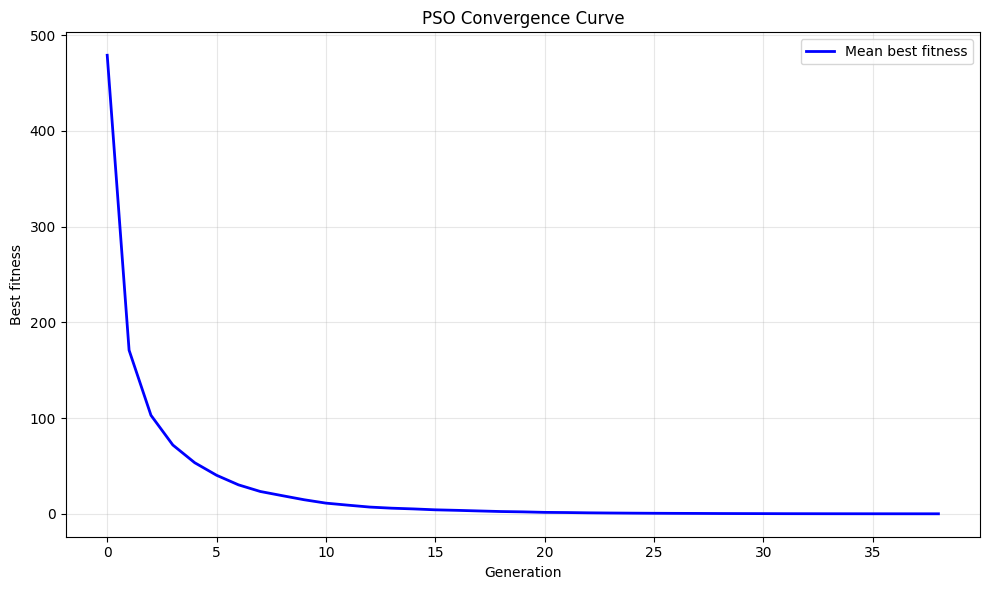

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Sphere Function
def sphere(x):
    return np.sum(x**2)

# PSO Single Run with early stopping threshold = 0.01
def pso_single_run(fitness_func, lb, ub, Np, T, w, c1, c2, d=10, threshold=0.01, return_history=True):
    # 1. Initialize random population and velocity within bounds
    pos = np.random.uniform(lb, ub, (Np, d))
    vel = np.zeros((Np, d))

    # 2. Evaluate objective function value of P
    fitness = np.array([fitness_func(ind) for ind in pos])

    # 3. Assign pbest as P and fpbest as f
    pbest = pos.copy()
    pbest_val = fitness.copy()

    # 4. Identify the solution with best fitness -> gbest
    gbest_idx = np.argmin(pbest_val)
    gbest = pbest[gbest_idx].copy()
    gbest_val = pbest_val[gbest_idx]

    # Record history (initial gbest)
    history = [gbest_val]

    # Main loop over generations
    for t in range(1, T + 1):
        # Early stopping: if gbest_val <= threshold (0.01), stop
        if gbest_val <= threshold:
            break

        # --- Determine velocities and new positions for all particles ---
        new_pos = np.zeros_like(pos)
        new_vel = np.zeros_like(vel)

        for i in range(Np):
            r1, r2 = np.random.rand(), np.random.rand()
            new_vel[i] = (w * vel[i] +
                          c1 * r1 * (pbest[i] - pos[i]) +
                          c2 * r2 * (gbest - pos[i]))
            new_pos[i] = pos[i] + new_vel[i]

        # --- Bound all new positions ---
        new_pos = np.clip(new_pos, lb, ub)

        # --- Evaluate all particles in the new population ---
        new_fitness = np.array([fitness_func(ind) for ind in new_pos])

        # --- Update personal bests and global best ---
        for i in range(Np):
            if new_fitness[i] < pbest_val[i]:
                pbest[i] = new_pos[i].copy()
                pbest_val[i] = new_fitness[i]

                if new_fitness[i] < gbest_val:
                    gbest = new_pos[i].copy()
                    gbest_val = new_fitness[i]

        # --- Replace old population with new one for next generation ---
        pos = new_pos
        vel = new_vel
        fitness = new_fitness

        # Record convergence
        history.append(gbest_val)

    if return_history:
        return gbest, gbest_val, history
    else:
        return gbest, gbest_val

# Multiple runs (with threshold)
def run_multiple_times(n_runs=20, Np=100, T=200, lb=-20, ub=20, d=10, threshold=0.01):
    # PSO parameters
    w, c1, c2 = 0.7, 1.5, 1.5

    histories = []
    final_fitnesses = []
    run_times = []
    gens_per_run = []   # track actual generations used

    for run in range(1, n_runs + 1):
        start = time.time()

        _, best_f, hist = pso_single_run(sphere, lb, ub, Np, T, w, c1, c2, d,
                                         threshold=threshold, return_history=True)

        elapsed = time.time() - start

        histories.append(hist)
        final_fitnesses.append(best_f)
        run_times.append(elapsed)
        gens_per_run.append(len(hist) - 1)   # exclude initial generation 0

        print(f"Run {run:2d}: Best fitness = {best_f:.6e}, Generations = {len(hist)-1}, Time = {elapsed:.2f} s")

    return histories, final_fitnesses, run_times, gens_per_run

# MAIN
if __name__ == "__main__":
    np.random.seed(42)

    n_runs = 20
    Np = 100
    T = 200
    lb, ub = -20, 20
    d = 10

    THRESHOLD = 0.01   # Early stopping threshold

    histories, final_fits, run_times, gens_per_run = run_multiple_times(
        n_runs, Np, T, lb, ub, d, threshold=THRESHOLD
    )

    # Summary
    avg_fit = np.mean(final_fits)
    std_fit = np.std(final_fits)
    best_fit = np.min(final_fits)
    worst_fit = np.max(final_fits)
    avg_time = np.mean(run_times)
    total_time = np.sum(run_times)
    avg_gens = np.mean(gens_per_run)
    std_gens = np.std(gens_per_run)

    print("\n" + "=" * 50)
    print(f"Summary over {n_runs} runs")
    print(f"Early stopping threshold: best_f <= {THRESHOLD}")
    print(f"Average best fitness : {avg_fit:.2e} ± {std_fit:.2e}")
    print(f"Best fitness         : {best_fit:.2e}")
    print(f"Worst fitness        : {worst_fit:.2e}")
    print(f"Average generations  : {avg_gens:.1f} ± {std_gens:.1f} (max {T})")
    print(f"Average time         : {avg_time:.2f} s")
    print(f"Total time           : {total_time:.2f} s")
    print("=" * 50)

    # Convergence graph (linear scale, no shaded region)
    # Truncate histories to shortest length due to early stopping
    min_len = min(len(h) for h in histories)
    truncated_hist = np.array([h[:min_len] for h in histories])
    mean_hist = np.mean(truncated_hist, axis=0)
    gens = np.arange(min_len)

    plt.figure(figsize=(10, 6))
    plt.plot(gens, mean_hist, 'b-', linewidth=2, label='Mean best fitness')
    plt.xlabel('Generation')
    plt.ylabel('Best fitness')
    plt.title(f'PSO Convergence Curve')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Sphere Function using TLBO

Run  1: Best fitness = 4.891265e-02, Generations = 200, Time = 2.82 s
Run  2: Best fitness = 7.232446e-03, Generations = 182, Time = 2.10 s
Run  3: Best fitness = 4.211799e-02, Generations = 200, Time = 2.32 s
Run  4: Best fitness = 4.902126e-02, Generations = 200, Time = 2.96 s
Run  5: Best fitness = 8.247364e-03, Generations = 200, Time = 2.85 s
Run  6: Best fitness = 1.705839e-02, Generations = 200, Time = 2.41 s
Run  7: Best fitness = 3.263611e-02, Generations = 200, Time = 2.34 s
Run  8: Best fitness = 1.066738e-02, Generations = 200, Time = 2.34 s
Run  9: Best fitness = 6.889275e-02, Generations = 200, Time = 2.86 s
Run 10: Best fitness = 1.534517e-02, Generations = 200, Time = 2.93 s
Run 11: Best fitness = 8.319491e-03, Generations = 197, Time = 2.28 s
Run 12: Best fitness = 5.300769e-02, Generations = 200, Time = 2.34 s
Run 13: Best fitness = 2.050407e-02, Generations = 200, Time = 3.89 s
Run 14: Best fitness = 1.027336e-02, Generations = 200, Time = 3.91 s
Run 15: Best fitness

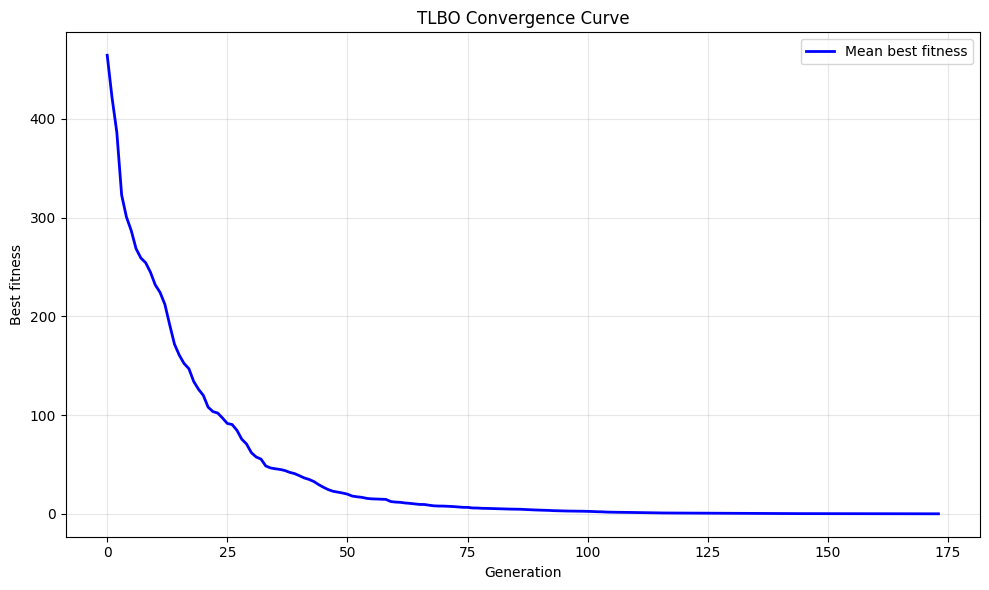

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Sphere Function
def sphere(x):
    return np.sum(x**2)

# TLBO Single Run with early stopping threshold = 0.01
def tlbo_single_run(fitness_func, lb, ub, Np, T, d=10, threshold=0.01, return_history=True):
    # Initialize random population
    population = np.random.uniform(lb, ub, (Np, d))
    fitness = np.array([fitness_func(ind) for ind in population])

    # Initial best
    best_idx = np.argmin(fitness)
    best_x = population[best_idx].copy()
    best_f = fitness[best_idx]
    history = [best_f]

    for t in range(1, T + 1):
        # Early stopping: if best_f <= threshold (0.01), stop
        if best_f <= threshold:
            break

        # For each particle sequentially
        for i in range(Np):
            # ----- Teacher phase
            # Choose X_best (current global best)
            X_best = population[np.argmin(fitness)]
            # Determine X_mean (mean of current population)
            X_mean = np.mean(population, axis=0)
            T_f = np.random.choice([1, 2])       # teaching factor
            r = np.random.rand()

            X_new = population[i] + r * (X_best - T_f * X_mean)
            X_new = np.clip(X_new, lb, ub)
            f_new = fitness_func(X_new)

            # Accept if better
            if f_new < fitness[i]:
                population[i] = X_new
                fitness[i] = f_new
                if f_new < best_f:
                    best_f = f_new
                    best_x = X_new.copy()

            # ----- Learner phase
            # Choose any solution randomly, X_p
            # Also choose X_j (another random solution, distinct from i and p)
            candidates = [idx for idx in range(Np) if idx != i]
            if len(candidates) >= 2:
                p, j = np.random.choice(candidates, size=2, replace=False)
            else:
                # Not enough distinct individuals – skip learner phase
                continue

            r = np.random.rand()
            if fitness[i] < fitness[p]:
                X_new = population[i] + r * (population[j] - population[p])
            else:
                X_new = population[i] - r * (population[j] - population[p])

            X_new = np.clip(X_new, lb, ub)
            f_new = fitness_func(X_new)

            if f_new < fitness[i]:
                population[i] = X_new
                fitness[i] = f_new
                if f_new < best_f:
                    best_f = f_new
                    best_x = X_new.copy()

        # Record best fitness of this generation
        history.append(best_f)

    if return_history:
        return best_x, best_f, history
    else:
        return best_x, best_f

# Multiple runs with threshold
def run_multiple_times(n_runs=20, Np=100, T=200, lb=-20, ub=20, d=10, threshold=0.01):
    histories = []
    final_fitnesses = []
    run_times = []
    gens_per_run = []   # track actual generations used

    for run in range(1, n_runs + 1):
        start = time.time()

        _, best_f, hist = tlbo_single_run(sphere, lb, ub, Np, T, d, threshold=threshold, return_history=True)

        elapsed = time.time() - start

        histories.append(hist)
        final_fitnesses.append(best_f)
        run_times.append(elapsed)
        gens_per_run.append(len(hist) - 1)   # exclude initial generation 0

        print(f"Run {run:2d}: Best fitness = {best_f:.6e}, Generations = {len(hist)-1}, Time = {elapsed:.2f} s")

    return histories, final_fitnesses, run_times, gens_per_run

# MAIN
if __name__ == "__main__":
    np.random.seed(42)

    n_runs = 20
    Np = 100
    T = 200
    lb, ub = -20, 20
    d = 10

    THRESHOLD = 0.01   # Early stopping threshold

    histories, final_fits, run_times, gens_per_run = run_multiple_times(
        n_runs, Np, T, lb, ub, d, threshold=THRESHOLD
    )

    # Summary
    avg_fit = np.mean(final_fits)
    std_fit = np.std(final_fits)
    best_fit = np.min(final_fits)
    worst_fit = np.max(final_fits)
    avg_time = np.mean(run_times)
    total_time = np.sum(run_times)
    avg_gens = np.mean(gens_per_run)
    std_gens = np.std(gens_per_run)

    print("\n" + "=" * 50)
    print(f"Summary over {n_runs} runs")
    print(f"Early stopping threshold: best_f <= {THRESHOLD}")
    print(f"Average best fitness : {avg_fit:.2e} ± {std_fit:.2e}")
    print(f"Best fitness         : {best_fit:.2e}")
    print(f"Worst fitness        : {worst_fit:.2e}")
    print(f"Average generations  : {avg_gens:.1f} ± {std_gens:.1f} (max {T})")
    print(f"Average time         : {avg_time:.2f} s")
    print(f"Total time           : {total_time:.2f} s")
    print("=" * 50)

    # Convergence graph (linear scale, no shaded region)
    # Truncate histories to shortest length due to early stopping
    min_len = min(len(h) for h in histories)
    truncated_hist = np.array([h[:min_len] for h in histories])
    mean_hist = np.mean(truncated_hist, axis=0)
    gens = np.arange(min_len)

    plt.figure(figsize=(10, 6))
    plt.plot(gens, mean_hist, 'b-', linewidth=2, label='Mean best fitness')
    plt.xlabel('Generation')
    plt.ylabel('Best fitness')
    plt.title(f'TLBO Convergence Curve')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Sphere Function using DE

Run  1: Best fitness = 6.789978e-03, Generations = 100, Time = 1.17 s
Run  2: Best fitness = 8.448510e-03, Generations = 98, Time = 0.94 s
Run  3: Best fitness = 8.963635e-03, Generations = 100, Time = 1.09 s
Run  4: Best fitness = 9.251944e-03, Generations = 92, Time = 1.05 s
Run  5: Best fitness = 9.454708e-03, Generations = 98, Time = 0.88 s
Run  6: Best fitness = 8.639954e-03, Generations = 103, Time = 0.76 s
Run  7: Best fitness = 6.742534e-03, Generations = 95, Time = 0.69 s
Run  8: Best fitness = 7.785826e-03, Generations = 100, Time = 0.70 s
Run  9: Best fitness = 7.885820e-03, Generations = 103, Time = 0.70 s
Run 10: Best fitness = 7.584610e-03, Generations = 101, Time = 0.74 s
Run 11: Best fitness = 9.143930e-03, Generations = 94, Time = 0.69 s
Run 12: Best fitness = 5.753854e-03, Generations = 100, Time = 0.74 s
Run 13: Best fitness = 8.203453e-03, Generations = 87, Time = 0.61 s
Run 14: Best fitness = 8.567501e-03, Generations = 97, Time = 0.69 s
Run 15: Best fitness = 9.40

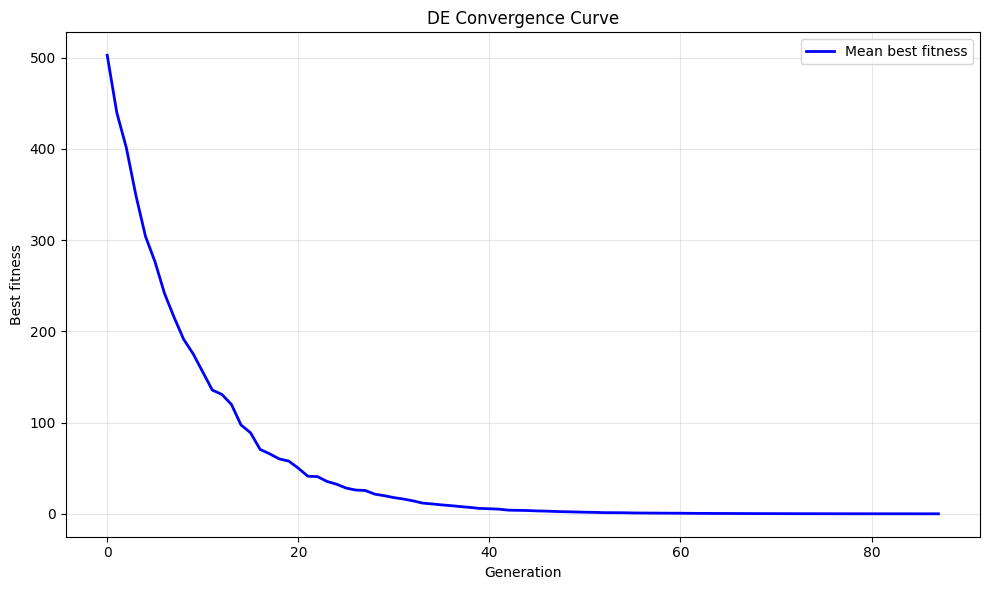

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Sphere Function
def sphere(x):
    return np.sum(x**2)

# DE Single Run with early stopping threshold = 0.01
def de_single_run(fitness_func, lb, ub, Np, T, d=10, threshold=0.01, return_history=True):

    F = 0.5      # mutation factor
    CR = 0.9     # crossover probability

    # Initialize population
    population = np.random.uniform(lb, ub, (Np, d))
    fitness = np.array([fitness_func(ind) for ind in population])

    best_idx = np.argmin(fitness)
    best_x = population[best_idx].copy()
    best_f = fitness[best_idx]
    history = [best_f]

    for t in range(1, T+1):
        # Early stopping: if best_f <= threshold (0.01), stop
        if best_f <= threshold:
            break

        for i in range(Np):
            # Select 3 random distinct individuals
            idxs = list(range(Np))
            idxs.remove(i)
            a, b, c = population[np.random.choice(idxs, 3, replace=False)]

            # Mutation: v = a + F*(b - c)
            v = a + F * (b - c)
            v = np.clip(v, lb, ub)

            # Crossover (binomial)
            u = np.copy(population[i])
            j_rand = np.random.randint(d)

            for j in range(d):
                if np.random.rand() < CR or j == j_rand:
                    u[j] = v[j]

            # Selection
            f_u = fitness_func(u)
            if f_u < fitness[i]:
                population[i] = u
                fitness[i] = f_u

                if f_u < best_f:
                    best_f = f_u
                    best_x = u.copy()

        history.append(best_f)

    if return_history:
        return best_x, best_f, history
    else:
        return best_x, best_f


# Multiple Runs with threshold
def run_multiple_times(n_runs=20, Np=100, T=200, lb=-20, ub=20, d=10, threshold=0.01):
    histories = []
    final_fitnesses = []
    run_times = []
    gens_per_run = []   # track actual generations used

    for run in range(1, n_runs+1):
        start = time.time()

        _, best_f, hist = de_single_run(sphere, lb, ub, Np, T, d, threshold=threshold, return_history=True)

        elapsed = time.time() - start

        histories.append(hist)
        final_fitnesses.append(best_f)
        run_times.append(elapsed)
        gens_per_run.append(len(hist) - 1)   # exclude initial generation 0

        print(f"Run {run:2d}: Best fitness = {best_f:.6e}, Generations = {len(hist)-1}, Time = {elapsed:.2f} s")

    return histories, final_fitnesses, run_times, gens_per_run


# ===== MAIN =====
if __name__ == "__main__":
    np.random.seed(42)

    n_runs = 20
    Np = 100
    T = 200
    lb, ub = -20, 20
    d = 10

    THRESHOLD = 0.01   # Early stopping threshold

    histories, final_fits, run_times, gens_per_run = run_multiple_times(
        n_runs, Np, T, lb, ub, d, threshold=THRESHOLD
    )

    # ===== Summary =====
    avg_fit = np.mean(final_fits)
    std_fit = np.std(final_fits)
    best_fit = np.min(final_fits)
    worst_fit = np.max(final_fits)
    avg_time = np.mean(run_times)
    total_time = np.sum(run_times)
    avg_gens = np.mean(gens_per_run)
    std_gens = np.std(gens_per_run)

    print("\n" + "="*50)
    print(f"Summary over {n_runs} runs")
    print(f"Early stopping threshold: best_f <= {THRESHOLD}")
    print(f"Average best fitness : {avg_fit:.2e} ± {std_fit:.2e}")
    print(f"Best fitness         : {best_fit:.2e}")
    print(f"Worst fitness        : {worst_fit:.2e}")
    print(f"Average generations  : {avg_gens:.1f} ± {std_gens:.1f} (max {T})")
    print(f"Average time         : {avg_time:.2f} s")
    print(f"Total time           : {total_time:.2f} s")
    print("="*50)

    # Convergence Graph (linear scale, no shaded region)
    # Truncate histories to shortest length due to early stopping
    min_len = min(len(h) for h in histories)
    truncated_hist = np.array([h[:min_len] for h in histories])
    mean_hist = np.mean(truncated_hist, axis=0)
    gens = np.arange(min_len)

    plt.figure(figsize=(10, 6))
    plt.plot(gens, mean_hist, 'b-', linewidth=2, label='Mean best fitness')
    plt.xlabel('Generation')
    plt.ylabel('Best fitness')
    plt.title(f'DE Convergence Curve')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Sphere Function using ABC

Run  1: Best Fitness = 6.094652e-03, Generations = 39, Time = 0.54 s
Run  2: Best Fitness = 8.180594e-03, Generations = 43, Time = 0.79 s
Run  3: Best Fitness = 8.343131e-03, Generations = 41, Time = 0.67 s
Run  4: Best Fitness = 5.322047e-03, Generations = 30, Time = 0.52 s
Run  5: Best Fitness = 9.215256e-03, Generations = 52, Time = 0.76 s
Run  6: Best Fitness = 7.058286e-03, Generations = 44, Time = 0.78 s
Run  7: Best Fitness = 9.914780e-03, Generations = 39, Time = 0.68 s
Run  8: Best Fitness = 7.602474e-03, Generations = 51, Time = 1.00 s
Run  9: Best Fitness = 8.300401e-03, Generations = 20, Time = 0.51 s
Run 10: Best Fitness = 8.426709e-03, Generations = 39, Time = 0.87 s
Run 11: Best Fitness = 9.834573e-03, Generations = 37, Time = 0.87 s
Run 12: Best Fitness = 2.088740e-03, Generations = 38, Time = 0.65 s
Run 13: Best Fitness = 8.078095e-03, Generations = 46, Time = 0.81 s
Run 14: Best Fitness = 8.813249e-03, Generations = 29, Time = 0.43 s
Run 15: Best Fitness = 8.797337e-0

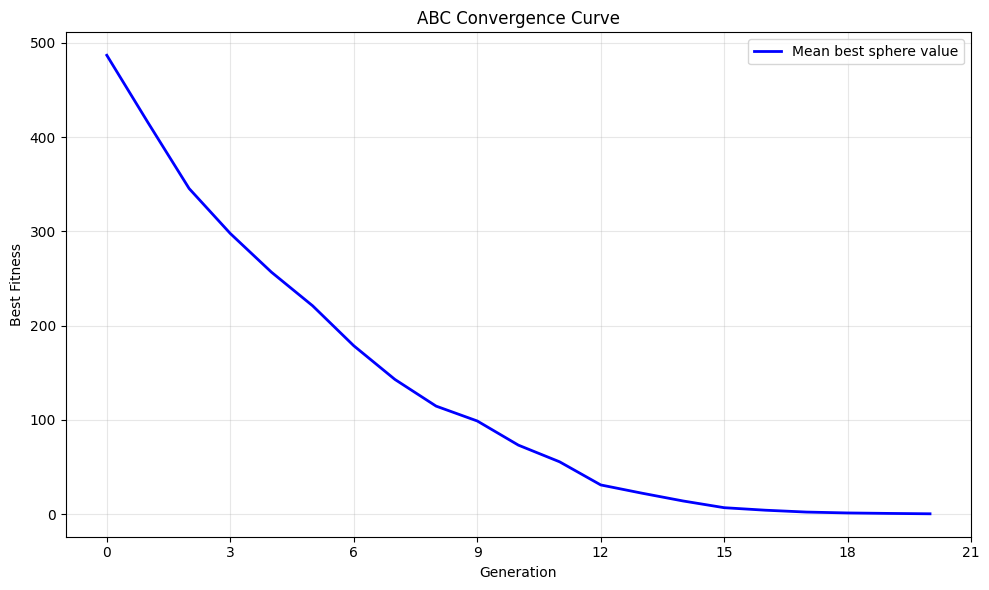

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

def sphere(x):
    """Sphere function (minimisation)."""
    return np.sum(x**2)

def abc_single_run(obj_func, lb, ub, Np, T, limit, d=10, threshold=0.01, return_history=True):
    """
    ABC with early stopping.

    Parameters:
        obj_func : callable (minimisation objective)
        lb, ub : float bounds
        Np : int (number of food sources = number of employed bees)
        T : int (generations)
        limit : int (scout threshold)
        d : int (dimensions)
        threshold : float (stop if best_obj <= threshold)
        return_history : bool
    """
    # Initialise population
    population = np.random.uniform(lb, ub, (Np, d))
    obj_vals = np.array([obj_func(ind) for ind in population])
    # Fitness for maximisation (used only for selection)
    fit_vals = 1.0 / (1.0 + obj_vals)
    trial = np.zeros(Np, dtype=int)

    # Initial best
    best_idx = np.argmax(fit_vals)
    best_x = population[best_idx].copy()
    best_obj = obj_vals[best_idx]
    history = [best_obj]

    for gen in range(1, T + 1):
        # Early stopping
        if best_obj <= threshold:
            break

        # ----- Employed Bee Phase -----
        for i in range(Np):
            # Choose random neighbour p != i
            p = np.random.choice([idx for idx in range(Np) if idx != i])
            j = np.random.randint(d)
            phi = np.random.uniform(-1, 1)
            new_x = population[i].copy()
            new_x[j] = population[i][j] + phi * (population[i][j] - population[p][j])
            new_x[j] = np.clip(new_x[j], lb, ub)
            new_obj = obj_func(new_x)
            new_fit = 1.0 / (1.0 + new_obj)
            if new_fit > fit_vals[i]:
                population[i] = new_x
                obj_vals[i] = new_obj
                fit_vals[i] = new_fit
                trial[i] = 0
            else:
                trial[i] += 1

        # ----- Determine probabilities for onlooker bees -----
        total_fit = np.sum(fit_vals)
        probs = fit_vals / total_fit if total_fit > 0 else np.ones(Np) / Np

        # ----- Onlooker Bee Phase -----
        for _ in range(Np):
            i = np.random.choice(Np, p=probs)
            p = np.random.choice([idx for idx in range(Np) if idx != i])
            j = np.random.randint(d)
            phi = np.random.uniform(-1, 1)
            new_x = population[i].copy()
            new_x[j] = population[i][j] + phi * (population[i][j] - population[p][j])
            new_x[j] = np.clip(new_x[j], lb, ub)
            new_obj = obj_func(new_x)
            new_fit = 1.0 / (1.0 + new_obj)
            if new_fit > fit_vals[i]:
                population[i] = new_x
                obj_vals[i] = new_obj
                fit_vals[i] = new_fit
                trial[i] = 0
            else:
                trial[i] += 1

        # ----- Scout Bee Phase -----
        exhausted = np.where(trial > limit)[0]
        if len(exhausted) > 0:
            i = exhausted[np.argmax(trial[exhausted])]
            population[i] = np.random.uniform(lb, ub, d)
            obj_vals[i] = obj_func(population[i])
            fit_vals[i] = 1.0 / (1.0 + obj_vals[i])
            trial[i] = 0

        # Memorise best
        current_best_idx = np.argmax(fit_vals)
        current_best_obj = obj_vals[current_best_idx]
        if current_best_obj < best_obj:
            best_obj = current_best_obj
            best_x = population[current_best_idx].copy()
        history.append(best_obj)

    if return_history:
        return best_x, best_obj, history
    else:
        return best_x, best_obj


def run_multiple_times(n_runs=20, Np=100, T=200, limit=20, lb=-20, ub=20, d=10, threshold=0.01):
    histories = []
    final_objs = []
    run_times = []
    gens_per_run = []

    for run in range(1, n_runs + 1):
        start = time.time()
        _, best_obj, hist = abc_single_run(sphere, lb, ub, Np, T, limit, d, threshold=threshold, return_history=True)
        elapsed = time.time() - start
        histories.append(hist)
        final_objs.append(best_obj)
        run_times.append(elapsed)
        gens_per_run.append(len(hist) - 1)
        print(f"Run {run:2d}: Best Fitness = {best_obj:.6e}, Generations = {len(hist)-1}, Time = {elapsed:.2f} s")

    return histories, final_objs, run_times, gens_per_run


if __name__ == "__main__":
    np.random.seed(42)
    n_runs = 20
    Np = 100
    T = 200
    limit = 20
    lb, ub = -20, 20
    d = 10
    THRESHOLD = 0.01

    histories, final_objs, run_times, gens_per_run = run_multiple_times(
        n_runs, Np, T, limit, lb, ub, d, threshold=THRESHOLD
    )

    # Summary statistics
    avg_obj = np.mean(final_objs)
    std_obj = np.std(final_objs)
    best_obj = np.min(final_objs)
    worst_obj = np.max(final_objs)
    avg_time = np.mean(run_times)
    total_time = np.sum(run_times)
    avg_gens = np.mean(gens_per_run)
    std_gens = np.std(gens_per_run)

    print("\n" + "=" * 50)
    print(f"Summary over {n_runs} runs")
    print(f"Early stopping threshold: best_obj <= {THRESHOLD}")
    print(f"Average best Fitness : {avg_obj:.2e} ± {std_obj:.2e}")
    print(f"Best Fitness        : {best_obj:.2e}")
    print(f"Worst Fitness        : {worst_obj:.2e}")
    print(f"Average generations    : {avg_gens:.1f} ± {std_gens:.1f} (max {T})")
    print(f"Average time           : {avg_time:.2f} s")
    print(f"Total time             : {total_time:.2f} s")
    print("=" * 50)

    # Convergence graph (linear scale, no shading, integer generation ticks)
    min_len = min(len(h) for h in histories)
    truncated_hist = np.array([h[:min_len] for h in histories])
    mean_hist = np.mean(truncated_hist, axis=0)
    gens = np.arange(min_len)  # integer array

    plt.figure(figsize=(10, 6))
    plt.plot(gens, mean_hist, 'b-', linewidth=2, label='Mean best sphere value')
    plt.xlabel('Generation')
    plt.ylabel('Best Fitness')
    plt.title(f'ABC Convergence Curve')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Force integer ticks on x-axis
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.show()